# Logistic Regression Classification on Ecommerce Data

This notebook demonstrates a **classification use case** using **Logistic Regression**.

## Objective
Predict whether an order is **returned (1)** or **not returned (0)** based on ecommerce order features.

## Dataset
- 1000 rows
- 10 columns
- Mix of categorical and numerical features

## Target Column
- `returned`


In [32]:
pip install -r requirements.txt

   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.6 MB 2.4 MB/s eta 0:00:06
   -- ------------------------------------- 1.0/14.6 MB 2.5 MB/s eta 0:00:06
   ----- ---------------------------------- 1.8/14.6 MB 2.9 MB/s eta 0:00:05
   ------- -------------------------------- 2.9/14.6 MB 3.2 MB/s eta 0:00:04
   --------- ------------------------------ 3.4/14.6 MB 3.2 MB/s eta 0:00:04
   ----------- ---------------------------- 4.2/14.6 MB 3.4 MB/s eta 0:00:04
   ------------ --------------------------- 4.5/14.6 MB 3.3 MB/s eta 0:00:04
   --------------- ------------------------ 5.5/14.6 MB 3.2 MB/s eta 0:00:03
   ----------------- ---------------------- 6.3/14.6 MB 3.2 MB/s eta 0:00:03
   -------------------- ------------------- 7.3/14.6 MB 3.4 MB/s eta 0:00:03
   -------------------- ------------------- 7.6/14.6 MB 3.2 MB/s eta 0:00:03
   ----------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

df = pd.read_csv('ecommerce_classification_data.csv')
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'ecommerce_classification_data.csv'

## 1. Basic exploration

In [3]:
print(df.head())


   order_id product_category customer_segment payment_method region  \
0     10001           Beauty            Loyal         Wallet  South   
1     10002           Sports        Returning           Card   West   
2     10003             Home        Returning           Card   East   
3     10004           Sports            Loyal         Wallet   West   
4     10005           Sports        Returning            COD   West   

   unit_price  quantity  discount_percent  customer_rating  returned  
0      504.45         4              9.42              4.3         0  
1     3168.36         4              6.95              3.2         0  
2     4908.71         4             27.42              3.3         0  
3     1072.02         2             31.82              2.8         0  
4     3994.09         5             12.96              4.1         0  


In [4]:
print(df.isnull().sum())

order_id            0
product_category    0
customer_segment    0
payment_method      0
region              0
unit_price          0
quantity            0
discount_percent    0
customer_rating     0
returned            0
dtype: int64


In [5]:
df = df.dropna()

## 2. Prepare features and target

In [22]:
X = df.drop('returned', axis=1)
y = df['returned']

## 3. Train-test split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 4. Build preprocessing + Logistic Regression pipeline

In [18]:
df = pd.get_dummies(df, columns=["region"])

bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [24]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 5. Predictions and evaluation

In [26]:
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

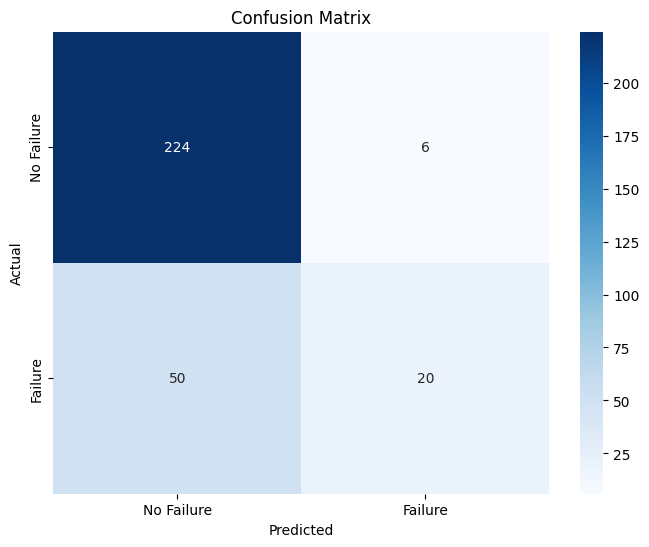

              precision    recall  f1-score   support

           0       0.82      0.97      0.89       230
           1       0.77      0.29      0.42        70

    accuracy                           0.81       300
   macro avg       0.79      0.63      0.65       300
weighted avg       0.81      0.81      0.78       300



In [27]:
import seaborn as sns
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()
print(classification_report(y_test, y_pred))

In [28]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.81


## 6. Predict on sample new records

## 7. Feature importance insight

For logistic regression, coefficients help us understand the direction of impact.


In [29]:
importance = log_reg.coef_[0]
features = X.columns

In [ ]:
feature_importance = pd.DataFrame({'Feature': features, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

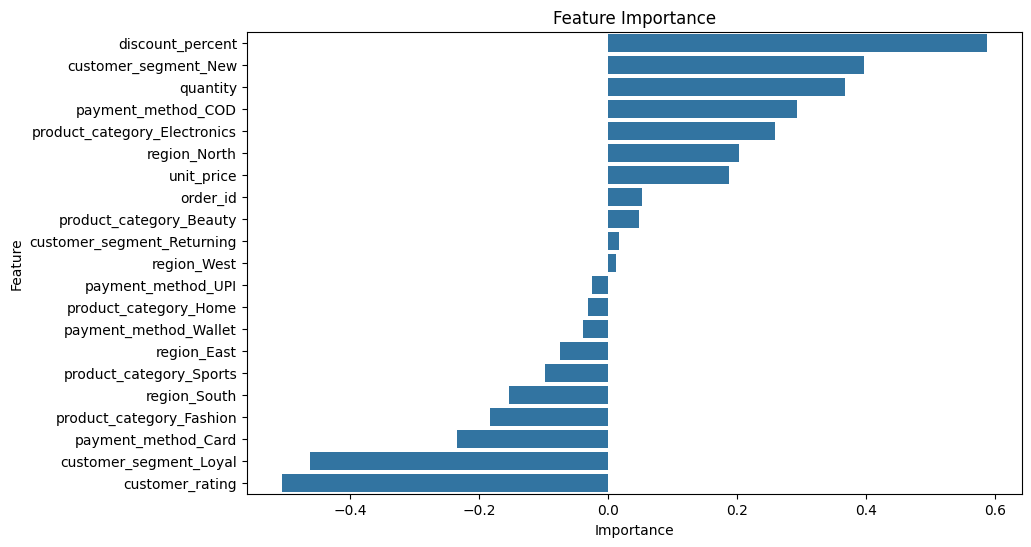

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.show()